# **Análisis Exploratorio Inicial**

En este notebook se analiza el dataset de ingreso de viajeros internacionales a Guatemala con el fin de comprender algunos de los comportamientos reflejados en los datos. Asimismo, se busca identificar potenciales errores como valores faltantes, duplicados y valores atípicos.

## Carga del dataset

Se carga la hoja `Datos` del archivo original a un DataFrame de pandas para el análisis.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta_dataset = "../datos/raw/Base_Migracion_2009-2026jun.xlsx"
viajeros_internacionales = pd.read_excel(ruta_dataset, sheet_name="Datos")

viajeros_internacionales["Periodo"] = pd.to_datetime(
    dict(year=viajeros_internacionales["Año"],
         month=viajeros_internacionales["Mes cod"],
         day=1)
).dt.to_period("M")

viajeros_internacionales.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Periodo
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01


## **Vías de ingreso y fronteras más utilizadas**

**Vías de Ingreso:**

La vía terrestre es la que concentra la mayor parte del flujo, representando el 61.19% de los viajeros del dataset con alrededor de 32.0 millones, y además es la que agrupa la mayor cantidad de registros, con un 78.16% del total de filas. Le sigue la vía aérea, que representa el 36.46% de los viajeros y alrededor de 19.1 millones, aunque cabe mencionar que lo hace con muchos menos registros (15.52%), lo cual tiene sentido ya que un solo vuelo mueve a muchos viajeros de una sola vez. Por último se tiene la vía marítima, que representa tan solo el 2.35% de los viajeros y alrededor de 1.23 millones, siendo la de menor peso dentro del período analizado.

**Viajeros por Frontera**

La frontera con mayor afluencia es La Aurora, que por sí sola concentra el 36.40% de los viajeros del dataset, con alrededor de 19.03 millones; cabe mencionar que casi todos estos viajeros ingresan por vía aérea, lo cual tiene sentido ya que La Aurora es el único aeropuerto principal con el que cuenta Guatemala, de tal forma que esta frontera concentra casi todo el flujo aéreo (cerca del 99.8% de sus viajeros) y explica por qué la vía aérea tiene tanto peso. Le sigue Valle Nuevo, con un 20.53% y alrededor de 10.73 millones de viajeros, y posteriormente San Cristóbal con un 10.26% (aproximadamente 5.36 millones) y Pedro de Alvarado con un 8.40% (alrededor de 4.39 millones), todas ellas fronteras terrestres. Cabe mencionar que el flujo está fuertemente concentrado, ya que entre las tres fronteras más transitadas se acumula el 67.19% de los viajeros y entre las cinco primeras el 81.10%, de tal forma que las 17 fronteras restantes reparten una porción bastante menor del total.

In [5]:
viajeros_por_via = (
    viajeros_internacionales
    .groupby("Vía")["Viajero"]
    .agg(registros="count", total_viajeros="sum")
    .sort_values("total_viajeros", ascending=False)
)
viajeros_por_via["porcentaje_viajeros"] = (
    viajeros_por_via["total_viajeros"] / viajeros_por_via["total_viajeros"].sum() * 100
).round(2)
viajeros_por_via

,registros,total_viajeros,porcentaje_viajeros
Vía,,,
Terrestre,125873,3.199530e+07,61.19
Aérea,24999,1.906385e+07,36.46
Marítima,10164,1.228782e+06,2.35


In [6]:
viajeros_por_frontera = (
    viajeros_internacionales
    .groupby("Frontera")["Viajero"]
    .agg(registros="count", total_viajeros="sum")
    .sort_values("total_viajeros", ascending=False)
)
viajeros_por_frontera["porcentaje_viajeros"] = (
    viajeros_por_frontera["total_viajeros"] / viajeros_por_frontera["total_viajeros"].sum() * 100
).round(2)
viajeros_por_frontera

,registros,total_viajeros,porcentaje_viajeros
Frontera,,,
01 La Aurora,21424,1.903440e+07,36.40
07 Valle Nuevo,13737,1.073234e+07,20.53
09 San Cristóbal,9067,5.363009e+06,10.26
08 Pedro de Alvarado,11558,4.393577e+06,8.40
10 La Ermita (Nueva Anguiatú),8831,2.879210e+06,5.51
20 Melchor de Mencos,12242,2.349551e+06,4.49
13 El Cinchado / El Corinto,10377,1.497006e+06,2.86
12 El Florido,11207,1.221040e+06,2.34
11 Agua Caliente,6390,1.154542e+06,2.21


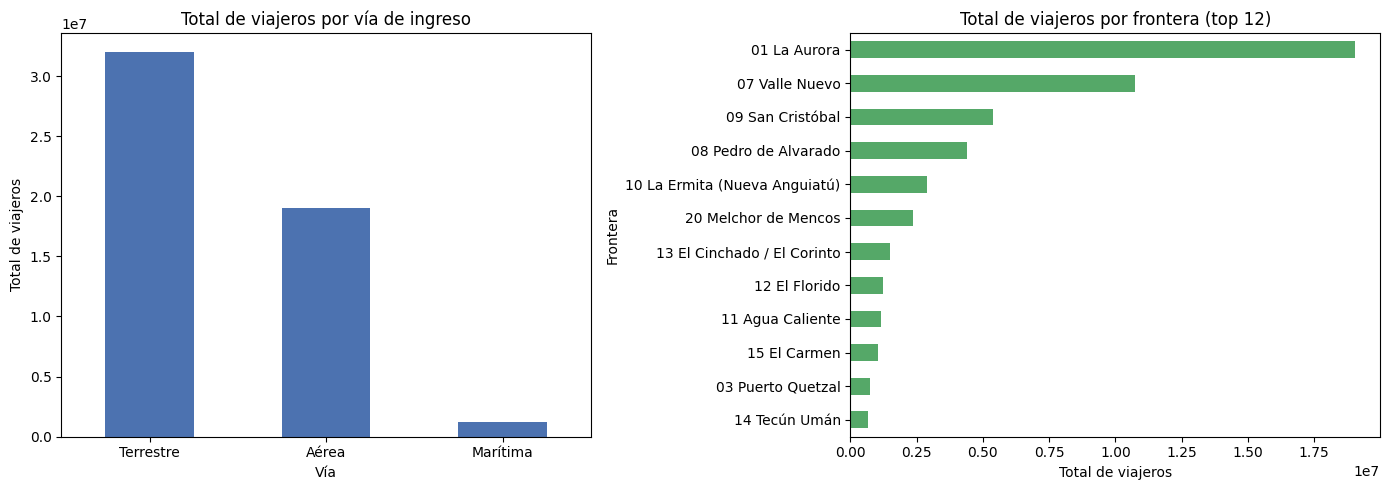

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

viajeros_por_via["total_viajeros"].plot(
    kind="bar", ax=ejes[0], color="#4C72B0")
ejes[0].set_title("Total de viajeros por vía de ingreso")
ejes[0].set_xlabel("Vía")
ejes[0].set_ylabel("Total de viajeros")
ejes[0].tick_params(axis="x", rotation=0)

viajeros_por_frontera["total_viajeros"].head(12).iloc[::-1].plot(
    kind="barh", ax=ejes[1], color="#55A868")
ejes[1].set_title("Total de viajeros por frontera (top 12)")
ejes[1].set_xlabel("Total de viajeros")
ejes[1].set_ylabel("Frontera")

plt.tight_layout()
plt.show()

## **Valores faltantes, duplicados y valores atípicos**

**Valores faltantes:**

Se logra evidenciar que el dataset no cuenta con datos explícitamente vacíos (NaN) para ninguna de sus variables. Adicional, se analizaron posibles faltantes disfrazados, es decir, valores que sin ser nulos representan una ausencia de dato, como espacios en blanco, guiones o marcadores del tipo 'na', 'nan', 'none', 'null', 'sin dato', 'no especificado' o 'desconocido', y tampoco se encontró ninguno de estos como parte del comportamiento de las variables categóricas. Asimismo, al tratarse de una serie de tiempo se revisó la completitud temporal, y de los 210 meses esperados entre enero de 2009 y junio de 2026 el dataset cuenta con las 210 observaciones, de tal forma que no existen huecos en el tiempo. Bajo esta idea, no es necesario aplicar ninguna técnica de imputación, ya que no hay datos faltantes que tratar.

**Duplicados:**

En cuanto a duplicados, no se encontró ninguna fila 100% idéntica, es decir, el total de las filas es distinto entre sí al considerar todas las columnas. Sin embargo, sí se presenta duplicidad parcial; para establecerla se evaluó una clave conformada por el año, el código del mes (el mes en su formato numérico del 1 al 12), la vía, la frontera, el país y el tipo de viajero, y bajo esta clave se encontraron 22 filas marcadas como duplicadas, que corresponden a 20 grupos de registros que comparten esa clave (42 filas involucradas en total). Tras analizar las filas involucradas en estos grupos, se encontró que lo único que difiere dentro de cada grupo es la Agrupación Residencia, de tal forma que un mismo país, en un mismo mes, frontera, vía y tipo de viajero, aparece repartido en dos (o hasta tres) agrupaciones de residencia distintas, cada una con su propia cantidad de viajeros. Por ejemplo, en abril de 2022 los turistas de Colombia que ingresaron por La Aurora aparecen divididos entre la agrupación 'Colombia' (2,610 viajeros) y 'Otros Suramérica' (1,051 viajeros), y de forma similar ocurre con España, Reino Unido o la Federación de Rusia. Es por esto que estas filas no representan un error ni un doble conteo, sino un nivel de detalle más fino, ya que la Agrupación Residencia forma parte de la verdadera granularidad de la tabla; de hecho, al incorporar esta columna a la clave, la duplicidad desaparece por completo (0 duplicados). Bajo este escenario, el manejo adecuado no es eliminar filas, sino reconocer que la clave que identifica de forma única cada registro debe incluir la Agrupación Residencia. Cabe mencionar que estos casos se concentran únicamente entre los años 2020 y 2022.

**Valores atípicos:**

Para los valores atípicos se recurrió a los diagramas de caja y bigote de la variable Viajero, junto con el criterio del rango intercuartílico (IQR). Bajo este criterio se marcan como atípicos 26,390 registros, es decir, alrededor del 16.39% del total, todos ellos por encima del límite superior de aproximadamente 94 viajeros por registro, ya que no hay atípicos por debajo dado que el mínimo es 0. Esto se evidencia en el gráfico por la gran cantidad de puntos que quedan por encima del bigote superior de la caja. No obstante, considero que estos valores no deben interpretarse directamente como errores, ya que la distribución de Viajero está fuertemente sesgada a la derecha: la mediana es de apenas 7 viajeros por registro, mientras que el máximo llega a 92,336, y es precisamente por ese sesgo que el criterio IQR termina señalando una cantidad tan grande de puntos. De hecho, aunque estos atípicos son solo el 16.39% de las filas, concentran alrededor del 96.68% del total de viajeros, lo que quiere decir que corresponden a los flujos legítimos de mayor volumen, como los de La Aurora por vía aérea. Es por esto que eliminarlos no sería adecuado, pues se estaría descartando prácticamente todo el turismo real registrado.

In [17]:
# Conteo de valores NaN por columna.
faltantes_por_columna = viajeros_internacionales.isna().sum()
faltantes_resumen = pd.DataFrame({
    "faltantes": faltantes_por_columna,
    "porcentaje": (faltantes_por_columna / len(viajeros_internacionales) * 100).round(2),
})
print("Total de valores NaN en todo el dataset:", int(faltantes_por_columna.sum()))
faltantes_resumen

Total de valores NaN en todo el dataset: 0


,faltantes,porcentaje
Año,0,0.0
Mes cod,0,0.0
Mes,0,0.0
Vía,0,0.0
Frontera,0,0.0
País,0,0.0
Región,0,0.0
Región dos,0,0.0
Regiones OMT,0,0.0
MCEO,0,0.0


In [18]:
# Búsqueda de faltantes disfrazados (cadenas vacías o marcadores tipo N/A) en las variables categóricas.
columnas_categoricas = [
    "Mes", "Vía", "Frontera", "País", "Región", "Región dos",
    "Regiones OMT", "MCEO", "Agrupación Residencia", "Tipo de Viajero",
]
marcadores_faltante = {
    "", "-", "--", "n/a", "na", "nan", "none", "null",
    "sin dato", "no especificado", "desconocido", "s/d",
}
faltantes_disfrazados = {}
for columna in columnas_categoricas:
    valores = viajeros_internacionales[columna].astype(str).str.strip()
    faltantes_disfrazados[columna] = int(valores.str.lower().isin(marcadores_faltante).sum())
faltantes_disfrazados = pd.Series(faltantes_disfrazados, name="faltantes_disfrazados")
print("Total de faltantes disfrazados detectados:", int(faltantes_disfrazados.sum()))
faltantes_disfrazados

Total de faltantes disfrazados detectados: 0


Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Name: faltantes_disfrazados, dtype: int64

In [19]:
# Verificación de que no falten meses entre el primer y el último período.
periodos_presentes = pd.PeriodIndex(viajeros_internacionales["Periodo"].unique())
rango_esperado = pd.period_range(periodos_presentes.min(), periodos_presentes.max(), freq="M")
meses_faltantes = rango_esperado.difference(periodos_presentes)

print("Primer mes:", rango_esperado.min(), "| Último mes:", rango_esperado.max())
print("Meses esperados:", len(rango_esperado))
print("Meses presentes:", periodos_presentes.nunique())
print("Meses faltantes (huecos):", len(meses_faltantes))
print("Registros con Viajero = 0:", int((viajeros_internacionales["Viajero"] == 0).sum()))

Primer mes: 2009-01 | Último mes: 2026-06
Meses esperados: 210
Meses presentes: 210
Meses faltantes (huecos): 0
Registros con Viajero = 0: 54


In [20]:
# Duplicados exactos y duplicados según clave parcial vs. clave completa.
print("Filas 100% idénticas:", int(viajeros_internacionales.duplicated().sum()))

clave_parcial = ["Año", "Mes cod", "Vía", "Frontera", "País", "Tipo de Viajero"]
clave_completa = clave_parcial + ["Agrupación Residencia"]

print("Duplicados según clave parcial :", int(viajeros_internacionales.duplicated(subset=clave_parcial).sum()))
print("Duplicados según clave completa:", int(viajeros_internacionales.duplicated(subset=clave_completa).sum()))

Filas 100% idénticas: 0
Duplicados según clave parcial : 22
Duplicados según clave completa: 0


In [21]:
# Comparación directa de las filas que comparten la clave parcial.
columnas_comparar = clave_parcial + ["Agrupación Residencia", "Viajero"]
comparacion_duplicados = (
    viajeros_internacionales[
        viajeros_internacionales.duplicated(subset=clave_parcial, keep=False)
    ]
    .sort_values(clave_parcial)
    [columnas_comparar]
    .reset_index(drop=True)
)
print("Filas involucradas en grupos con clave parcial repetida:", len(comparacion_duplicados))
comparacion_duplicados

Filas involucradas en grupos con clave parcial repetida: 42


,Año,Mes cod,Vía,Frontera,País,Tipo de Viajero,Agrupación Residencia,Viajero
0,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,3.0
1,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Resto del Mundo,1.0
2,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,44.0
3,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,Resto del Mundo,223.0
4,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,4.0
5,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Resto del Mundo,1.0
6,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,Estados Unidos de América,7.0
7,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,México,13.0
8,2022,4,Aérea,01 La Aurora,Colombia,Turista,Colombia,2610.0
9,2022,4,Aérea,01 La Aurora,Colombia,Turista,Otros Suramérica,1051.0


In [22]:
# Conteo de valores atípicos de Viajero con el criterio IQR (1.5 * IQR).
cuartil_1 = viajeros_internacionales["Viajero"].quantile(0.25)
cuartil_3 = viajeros_internacionales["Viajero"].quantile(0.75)
rango_intercuartilico = cuartil_3 - cuartil_1
limite_inferior = cuartil_1 - 1.5 * rango_intercuartilico
limite_superior = cuartil_3 + 1.5 * rango_intercuartilico

es_atipico = (viajeros_internacionales["Viajero"] < limite_inferior) | (viajeros_internacionales["Viajero"] > limite_superior)

print(f"Q1 = {cuartil_1:.2f} | Q3 = {cuartil_3:.2f} | IQR = {rango_intercuartilico:.2f}")
print(f"Límites del criterio IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Valores atípicos: {int(es_atipico.sum())} ({es_atipico.mean() * 100:.2f}% del total)")
print(f"Viajeros concentrados en los atípicos: "
      f"{viajeros_internacionales.loc[es_atipico, 'Viajero'].sum() / viajeros_internacionales['Viajero'].sum() * 100:.2f}%")

Q1 = 2.00 | Q3 = 38.89 | IQR = 36.89
Límites del criterio IQR: [-53.34, 94.23]
Valores atípicos: 26390 (16.39% del total)
Viajeros concentrados en los atípicos: 96.68%


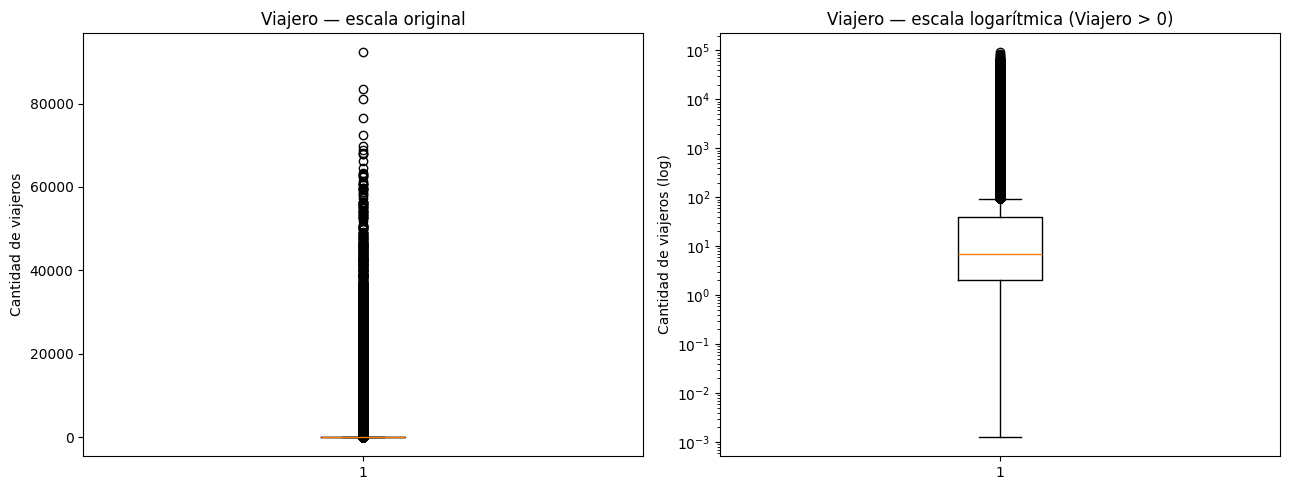

In [23]:
# Diagrama de caja y bigote de Viajero (escala original y logarítmica).
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

ejes[0].boxplot(viajeros_internacionales["Viajero"])
ejes[0].set_title("Viajero — escala original")
ejes[0].set_ylabel("Cantidad de viajeros")

viajeros_positivos = viajeros_internacionales.loc[viajeros_internacionales["Viajero"] > 0, "Viajero"]
ejes[1].boxplot(viajeros_positivos)
ejes[1].set_yscale("log")
ejes[1].set_title("Viajero — escala logarítmica (Viajero > 0)")
ejes[1].set_ylabel("Cantidad de viajeros (log)")

plt.tight_layout()
plt.show()

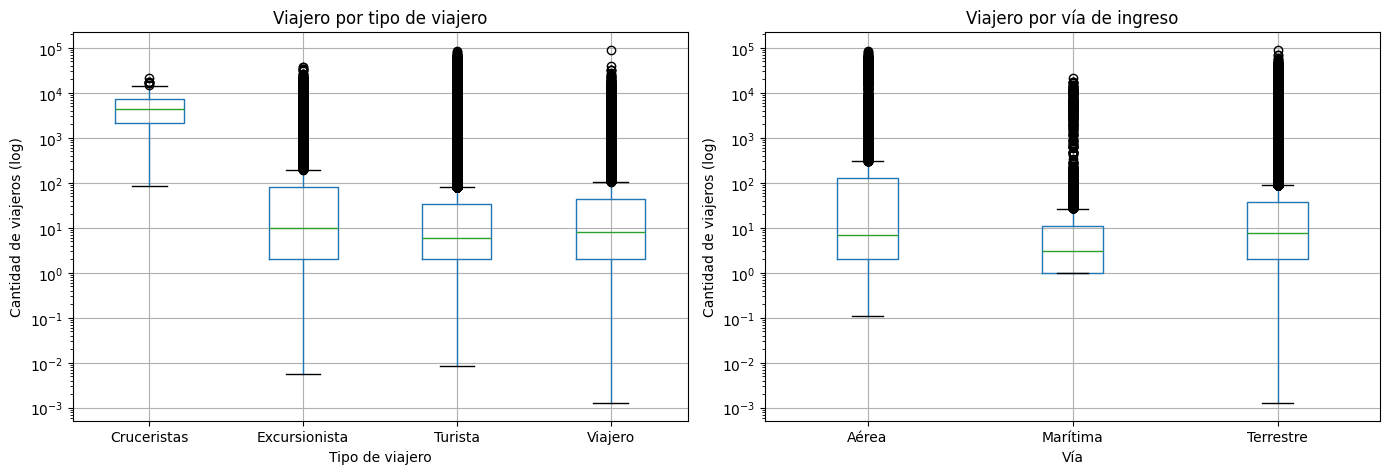

In [24]:
# Diagramas de caja y bigote de Viajero por tipo de viajero y por vía.
positivos = viajeros_internacionales[viajeros_internacionales["Viajero"] > 0]

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

positivos.boxplot(column="Viajero", by="Tipo de Viajero", ax=ejes[0])
ejes[0].set_yscale("log")
ejes[0].set_title("Viajero por tipo de viajero")
ejes[0].set_xlabel("Tipo de viajero")
ejes[0].set_ylabel("Cantidad de viajeros (log)")

positivos.boxplot(column="Viajero", by="Vía", ax=ejes[1])
ejes[1].set_yscale("log")
ejes[1].set_title("Viajero por vía de ingreso")
ejes[1].set_xlabel("Vía")
ejes[1].set_ylabel("Cantidad de viajeros (log)")

plt.suptitle("")
plt.tight_layout()
plt.show()

## **Estadísticas descriptivas y visualizaciones**

**Estadísticas descriptivas (variables numéricas):**

Como aclaración inicial, cabe mencionar que las variables Año y Mes cod no se analizaron mediante estadística descriptiva, ya que por su naturaleza funcionan como identificadores temporales y no como magnitudes, de tal forma que calcular su media o desviación estándar no revelaría nada relevante sobre el comportamiento de los datos. Es por esto que la descripción numérica se centra únicamente en la variable Viajero. En este caso sí vale la pena discutirla, y de entrada llama la atención que el mínimo es 0, lo cual, tal como se mencionó en el análisis de valores faltantes, no representa un dato ausente sino registros donde simplemente no hubo flujo para esa combinación, por lo que se trata de la misma forma, es decir, como un valor válido. Asimismo, esta variable conecta directamente con la discusión de los valores atípicos, ya que se observa que el 75% de los registros tiene 38.89 viajeros o menos, mientras que el máximo llega hasta 92,336, y esa distancia tan grande entre el tercer cuartil y el máximo confirma el fuerte sesgo a la derecha de la distribución; algo similar refleja el hecho de que la media (324.70) sea muy superior a la mediana (7), lo cual ocurre justamente porque unos pocos registros de gran volumen jalan el promedio hacia arriba.

**Estadísticas descriptivas (variables categóricas):**

Para las variables categóricas lo que interesa discutir es la categoría más frecuente y la frecuencia con la que aparece, de tal forma que se pueda contrastar si existe cierta concentración en valores específicos. Bajo esta idea, se evidencia que algunas variables están bastante concentradas, como la vía, donde el 78.2% de los registros corresponde a la vía terrestre, o el tipo de viajero, donde el 73.2% corresponde a turistas, e incluso el MCEO, donde casi la mitad (45.4%) cae en la agrupación '08 OTROS'. Por otro lado, hay variables mucho más dispersas, como el país, donde la categoría más frecuente (Guatemala) apenas representa el 3.9% del total, lo cual tiene sentido ya que esta variable llega a tener hasta 235 categorías distintas y por lo tanto la frecuencia se reparte entre muchas más opciones. En términos generales, esto nos dice que la concentración no es uniforme entre variables, y que hay dimensiones dominadas por una sola categoría mientras que otras distribuyen sus registros de forma más pareja.

**Distribución de la cantidad de viajeros:**

El histograma de la cantidad de viajeros por registro no aporta un hallazgo nuevo por sí mismo, sino que sirve para reforzar visualmente lo que ya se había visto en el análisis de valores atípicos, es decir, que la gran mayoría de los registros se acumula en valores bajos y que solo una porción pequeña alcanza cantidades muy altas, lo cual vuelve a evidenciar el sesgo hacia la derecha de la distribución.

**Visitantes mensuales:**

Al analizar los visitantes mensuales aquí sí vale la pena detenerse, ya que se logra ver una tendencia de crecimiento bastante clara desde el 2009 hasta finales del 2019, alcanzando su punto más alto en diciembre de 2019 con alrededor de 449 mil visitantes en un solo mes. No obstante, a partir de marzo de 2020 se observa una caída abrupta que prácticamente lleva la serie a cero, tocando su punto más bajo en mayo de 2020 con apenas 9,779 visitantes, lo cual se debe totalmente a la pandemia, y durante todo ese transcurso se nota una caída considerable en la cantidad de turismo. Ya después, a partir del 2022, se evidencia que la cantidad de turismo vuelve a incrementar, retomando nuevamente una tendencia al alza.

In [30]:
# Estadísticas descriptivas de la variable Viajero (Año y Mes cod se omiten por ser identificadores temporales).
viajeros_internacionales[["Viajero"]].describe()

,Viajero
count,161036.000000
mean,324.697193
std,2387.745140
min,0.000000
25%,2.000000
50%,7.000000
75%,38.891667
max,92336.035067


In [31]:
# Para cada variable categórica: número de categorías, categoría más frecuente y su frecuencia.
resumen_categoricas = pd.DataFrame({
    "n_categorias": [viajeros_internacionales[c].nunique() for c in columnas_categoricas],
    "categoria_mas_frecuente": [viajeros_internacionales[c].mode()[0] for c in columnas_categoricas],
    "frecuencia": [viajeros_internacionales[c].value_counts().iloc[0] for c in columnas_categoricas],
})
resumen_categoricas.index = columnas_categoricas
resumen_categoricas["porcentaje"] = (
    resumen_categoricas["frecuencia"] / len(viajeros_internacionales) * 100
).round(1)
resumen_categoricas

,n_categorias,categoria_mas_frecuente,frecuencia,porcentaje
Mes,12,Ene,14726,9.1
Vía,3,Terrestre,125873,78.2
Frontera,22,01 La Aurora,21424,13.3
País,235,Guatemala,6319,3.9
Región,17,EUROPA,32331,20.1
Región dos,11,Europa,54640,33.9
Regiones OMT,26,AMÉRICA CENTRAL,31362,19.5
MCEO,8,08 OTROS,73173,45.4
Agrupación Residencia,33,Europa,46761,29.0
Tipo de Viajero,4,Turista,117912,73.2


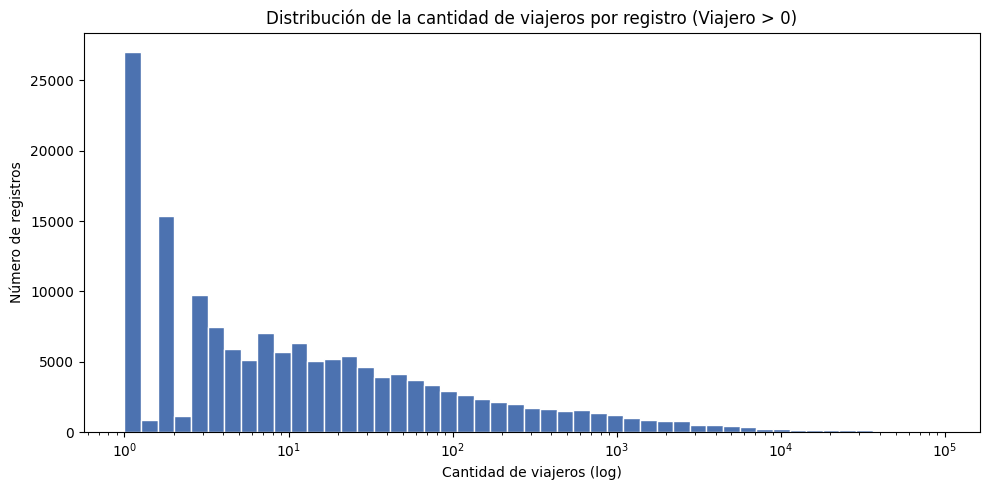

In [32]:
# Distribución de la cantidad de viajeros por registro (escala logarítmica por el fuerte sesgo).
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(viajeros_internacionales.loc[viajeros_internacionales["Viajero"] > 0, "Viajero"],
        bins=np.logspace(0, np.log10(viajeros_internacionales["Viajero"].max()), 50),
        color="#4C72B0", edgecolor="white")
ax.set_xscale("log")
ax.set_title("Distribución de la cantidad de viajeros por registro (Viajero > 0)")
ax.set_xlabel("Cantidad de viajeros (log)")
ax.set_ylabel("Número de registros")
plt.tight_layout()
plt.show()

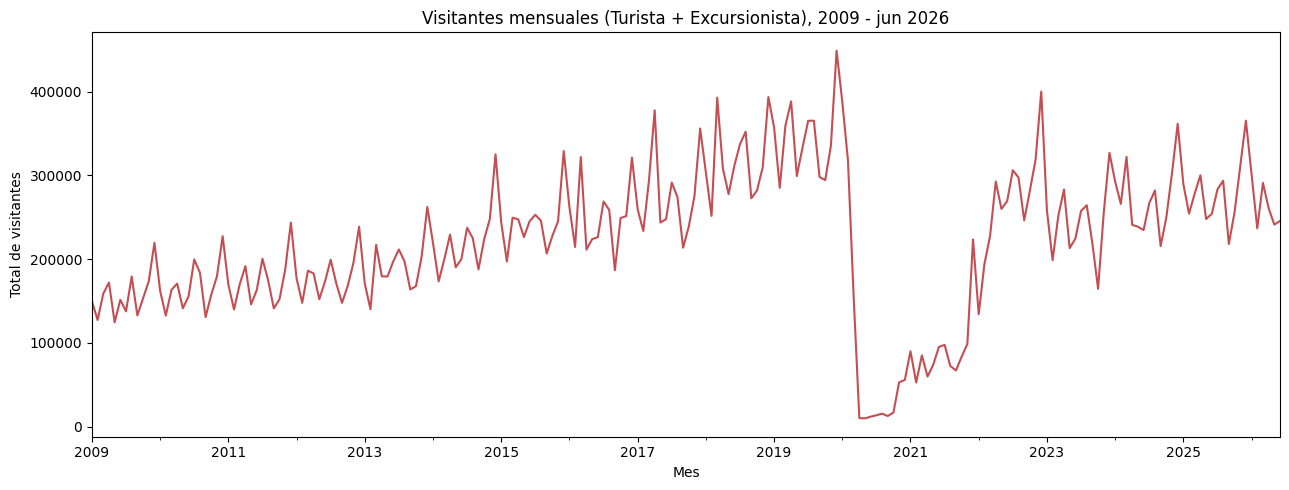

In [33]:
# Serie de tiempo del total mensual de visitantes (Turista + Excursionista, consistentes en todo el período).
visitantes_mensuales = (
    viajeros_internacionales[
        viajeros_internacionales["Tipo de Viajero"].isin(["Turista", "Excursionista"])
    ]
    .groupby("Periodo")["Viajero"]
    .sum()
)

fig, ax = plt.subplots(figsize=(13, 5))
visitantes_mensuales.plot(ax=ax, color="#C44E52")
ax.set_title("Visitantes mensuales (Turista + Excursionista), 2009 - jun 2026")
ax.set_xlabel("Mes")
ax.set_ylabel("Total de visitantes")
plt.tight_layout()
plt.show()